<a href="https://colab.research.google.com/github/eelah200/Numerical-Analysis/blob/main/%EC%88%98%EC%B9%98%ED%95%B4%EC%84%9D_%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C_%EA%B5%AC%ED%98%84%EC%BD%94%EB%93%9C(202022417_%EC%9D%B4%ED%95%98%EC%9C%A4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###A-1 코드###

In [ ]:
import tensorflow as tf

In [ ]:
mnist = tf.keras.datasets.mnist

# MNIST 데이터 로딩: #(train data)=60,000, #(test data)=10,000
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# 60,000개의 data --> 훈련(train)데이터, 검증(validation) 데이터로 나눔
x_valid, x_train = x_train_full[:5000], x_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
###[A]-1 : Adam 알고리즘 이용###

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # 입력층 : 뉴런 수 28x28
  tf.keras.layers.Dense(128, activation='sigmoid'),  # 활성화 함수 선택: Sigmoid
  tf.keras.layers.Dense(10, activation='softmax') # 출력층: 뉴런 수 10개, 활성화함수(Softmax)
])

model.compile(optimizer='adam',                     #최적화 알고리즘 선택 예: SGD 또는 Adam
              loss='sparse_categorical_crossentropy', #cross-entropy 함수
              metrics=['accuracy'])

In [ ]:
History = model.fit(x_train, \
                    y_train, \
                    epochs=10,\
                    validation_data=(x_valid,y_valid))   # 최대 epoch 수 : 10회

print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

Epoch 1/10
1719/1719 [==============================] - 12s 6ms/step - loss: 0.4190 - accuracy: 0.8911 - val_loss: 0.2232 - val_accuracy: 0.9364
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2043 - accuracy: 0.9409 - val_loss: 0.1632 - val_accuracy: 0.9544
Epoch 3/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.1521 - accuracy: 0.9549 - val_loss: 0.1342 - val_accuracy: 0.9630
Epoch 4/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.1192 - accuracy: 0.9666 - val_loss: 0.1095 - val_accuracy: 0.9700
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0958 - accuracy: 0.9732 - val_loss: 0.0986 - val_accuracy: 0.9718
Epoch 6/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0795 - accuracy: 0.9773 - val_loss: 0.0900 - val_accuracy: 0.9736
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0661 - accuracy: 0.9815 - val_loss: 0.0833 - val_accuracy

[0.07812735438346863, 0.973800003528595]

In [ ]:
History.history

{'loss': [0.4189999997615814,
  0.20430666208267212,
  0.1520833522081375,
  0.11915730684995651,
  0.09581241011619568,
  0.07949470728635788,
  0.06611056625843048,
  0.055222347378730774,
  0.04650898277759552,
  0.038702771067619324],
 'accuracy': [0.8911272883415222,
  0.940890908241272,
  0.9549272656440735,
  0.9665636420249939,
  0.9731636643409729,
  0.9772909283638,
  0.9815090894699097,
  0.9840909242630005,
  0.9874908924102783,
  0.9896000027656555],
 'val_loss': [0.22322915494441986,
  0.16317392885684967,
  0.13419391214847565,
  0.10949576646089554,
  0.09861914813518524,
  0.09001016616821289,
  0.08325083553791046,
  0.08038917183876038,
  0.07536313682794571,
  0.07519732415676117],
 'val_accuracy': [0.9363999962806702,
  0.9544000029563904,
  0.9629999995231628,
  0.9700000286102295,
  0.9718000292778015,
  0.9735999703407288,
  0.9753999710083008,
  0.9760000109672546,
  0.9779999852180481,
  0.9768000245094299]}

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


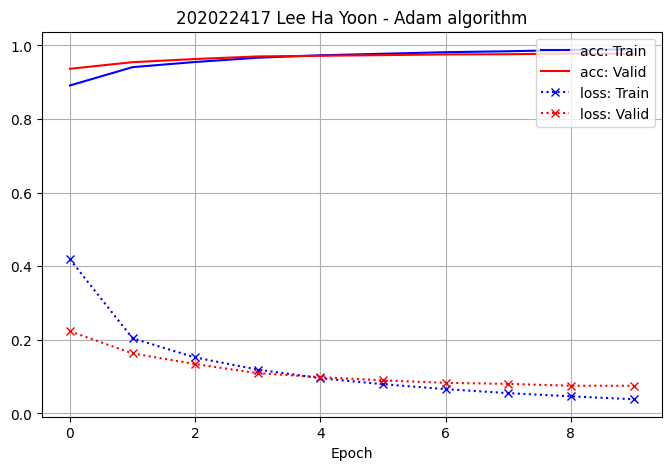

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - Adam algorithm')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()

In [ ]:
###[A]-1 : SGD 알고리즘 이용###

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # 입력층 : 뉴런 수 28x28
  tf.keras.layers.Dense(128, activation='sigmoid'),  # 활성화 함수 선택: Sigmoid
  tf.keras.layers.Dense(10, activation='softmax') # 출력층: 뉴런 수 10개, 활성화함수(Softmax)
])

model.compile(optimizer='sgd',                     #최적화 알고리즘 선택 예: SGD 또는 Adam
              loss='sparse_categorical_crossentropy', #cross-entropy 함수
              metrics=['accuracy'])

In [ ]:
History = model.fit(x_train, \
                    y_train, \
                    epochs=10,\
                    validation_data=(x_valid,y_valid))   # 최대 epoch 수 : 10회

print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 1.5040 - accuracy: 0.6914 - val_loss: 0.9307 - val_accuracy: 0.8232
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7440 - accuracy: 0.8425 - val_loss: 0.5974 - val_accuracy: 0.8644
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5488 - accuracy: 0.8688 - val_loss: 0.4798 - val_accuracy: 0.8830
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4670 - accuracy: 0.8813 - val_loss: 0.4205 - val_accuracy: 0.8906
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4218 - accuracy: 0.8880 - val_loss: 0.3845 - val_accuracy: 0.8980
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3929 - accuracy: 0.8932 - val_loss: 0.3610 - val_accuracy: 0.9030
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3722 - accuracy: 0.8968 - val_loss: 0.3431 - val_accuracy:

[0.31489288806915283, 0.9118000268936157]

In [ ]:
History.history

{'loss': [1.5040075778961182,
  0.744005560874939,
  0.5488498210906982,
  0.46696531772613525,
  0.4217793345451355,
  0.39287590980529785,
  0.3722130358219147,
  0.35669687390327454,
  0.34439143538475037,
  0.33426564931869507],
 'accuracy': [0.6914181709289551,
  0.8425090909004211,
  0.8688363432884216,
  0.8813454508781433,
  0.8880000114440918,
  0.8931999802589417,
  0.8967818021774292,
  0.8998181819915771,
  0.9026545286178589,
  0.904945433139801],
 'val_loss': [0.9307456016540527,
  0.5973976254463196,
  0.47975650429725647,
  0.42053452134132385,
  0.38447847962379456,
  0.36099734902381897,
  0.34313634037971497,
  0.3309299945831299,
  0.3194485008716583,
  0.30961889028549194],
 'val_accuracy': [0.823199987411499,
  0.8644000291824341,
  0.8830000162124634,
  0.8906000256538391,
  0.8980000019073486,
  0.902999997138977,
  0.9067999720573425,
  0.9079999923706055,
  0.9106000065803528,
  0.9125999808311462]}

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


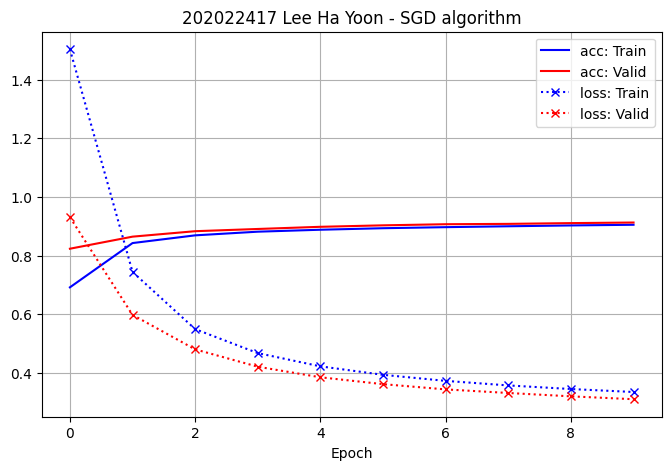

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - SGD algorithm')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()

In [ ]:
###A-2###

In [ ]:
import tensorflow as tf

In [ ]:
mnist = tf.keras.datasets.mnist

# MNIST 데이터 로딩: #(train data)=60,000, #(test data)=10,000
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# 60,000개의 data --> 훈련(train)데이터, 검증(validation) 데이터로 나눔
x_valid, x_train = x_train_full[:5000], x_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [ ]:
###[A]-2 : ReLU 함수 이용###

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # 입력층 : 뉴런 수 28x28
  tf.keras.layers.Dense(128, activation='relu'),  # 활성화 함수 선택: sigmoid 또는 ReLU
  tf.keras.layers.Dropout(0.2),                   # dropout 비율: 0.2
  tf.keras.layers.Dense(10, activation='softmax') # 출력층: 뉴런 수 10개, 활성화함수(Softmax)
])

model.compile(optimizer='adam',                     #최적화 알고리즘 선택: Adam
              loss='sparse_categorical_crossentropy', #cross-entropy 함수
              metrics=['accuracy'])

In [ ]:
History = model.fit(x_train, \
                    y_train, \
                    epochs=10,\
                    validation_data=(x_valid,y_valid))   # 최대 epoch 수 : 10회

print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3037 - accuracy: 0.9115 - val_loss: 0.1416 - val_accuracy: 0.9610
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.1475 - accuracy: 0.9558 - val_loss: 0.1078 - val_accuracy: 0.9690
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.1108 - accuracy: 0.9666 - val_loss: 0.0899 - val_accuracy: 0.9726
Epoch 4/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0904 - accuracy: 0.9717 - val_loss: 0.0871 - val_accuracy: 0.9730
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0762 - accuracy: 0.9764 - val_loss: 0.0728 - val_accuracy: 0.9784
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0676 - accuracy: 0.9781 - val_loss: 0.0826 - val_accuracy: 0.9766
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0589 - accuracy: 0.9809 - val_loss: 0.0732 - val_accuracy:

[0.07722149789333344, 0.9775000214576721]

In [ ]:
History.history

{'loss': [0.30369943380355835,
  0.14749062061309814,
  0.11082270741462708,
  0.09041421115398407,
  0.07622988522052765,
  0.06756298243999481,
  0.05893964320421219,
  0.05218157544732094,
  0.048362620174884796,
  0.04268134385347366],
 'accuracy': [0.9114909172058105,
  0.9558181762695312,
  0.9665818214416504,
  0.9717454314231873,
  0.9763636589050293,
  0.9781273007392883,
  0.9808727502822876,
  0.9824545383453369,
  0.9842545390129089,
  0.9858909249305725],
 'val_loss': [0.1415957808494568,
  0.10775423794984818,
  0.08989206701517105,
  0.08708354830741882,
  0.07275888323783875,
  0.08261041343212128,
  0.07321218401193619,
  0.07384529709815979,
  0.07339499890804291,
  0.08536255359649658],
 'val_accuracy': [0.9610000252723694,
  0.968999981880188,
  0.972599983215332,
  0.9729999899864197,
  0.9783999919891357,
  0.9765999913215637,
  0.9787999987602234,
  0.9793999791145325,
  0.9793999791145325,
  0.9760000109672546]}

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


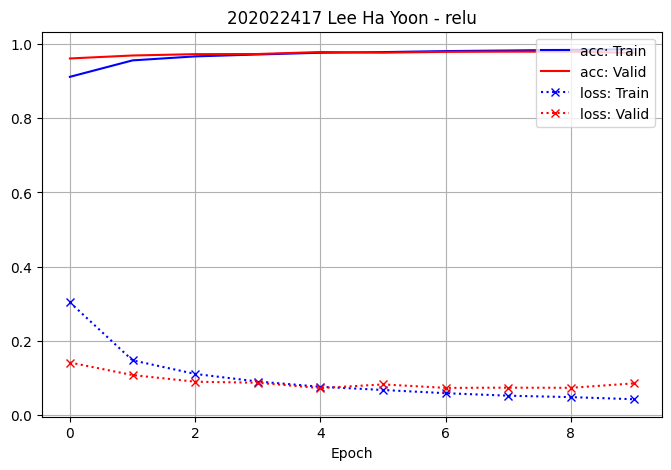

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - relu')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()

In [ ]:
###[A]-2 : Sigmoid 함수 이용###

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # 입력층 : 뉴런 수 28x28
  tf.keras.layers.Dense(128, activation='sigmoid'),  # 활성화 함수 선택: sigmoid 또는 ReLU
  tf.keras.layers.Dropout(0.2),                   # dropout 비율: 0.2
  tf.keras.layers.Dense(10, activation='softmax') # 출력층: 뉴런 수 10개, 활성화함수(Softmax)
])

model.compile(optimizer='adam',                     #최적화 알고리즘 선택: Adam
              loss='sparse_categorical_crossentropy', #cross-entropy 함수
              metrics=['accuracy'])

In [ ]:
History = model.fit(x_train, \
                    y_train, \
                    epochs=10,\
                    validation_data=(x_valid,y_valid))   # 최대 epoch 수 : 10회

print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4636 - accuracy: 0.8724 - val_loss: 0.2300 - val_accuracy: 0.9340
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2399 - accuracy: 0.9297 - val_loss: 0.1698 - val_accuracy: 0.9524
Epoch 3/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.1833 - accuracy: 0.9462 - val_loss: 0.1425 - val_accuracy: 0.9602
Epoch 4/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.1472 - accuracy: 0.9564 - val_loss: 0.1186 - val_accuracy: 0.9668
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.1235 - accuracy: 0.9635 - val_loss: 0.1047 - val_accuracy: 0.9694
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.1089 - accuracy: 0.9672 - val_loss: 0.0936 - val_accuracy: 0.9734
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0944 - accuracy: 0.9717 - val_loss: 0.0903 - val_accuracy:

[0.07967699319124222, 0.9761000275611877]

In [ ]:
History.history

{'loss': [0.46364331245422363,
  0.23986567556858063,
  0.18334579467773438,
  0.1472170203924179,
  0.12349281460046768,
  0.10886583477258682,
  0.09441119432449341,
  0.08535333722829819,
  0.0743575394153595,
  0.06918609142303467],
 'accuracy': [0.8723818063735962,
  0.9297454357147217,
  0.9461818337440491,
  0.9564363360404968,
  0.963490903377533,
  0.967236340045929,
  0.9716908931732178,
  0.9734545350074768,
  0.9776545166969299,
  0.9788908958435059],
 'val_loss': [0.2300097644329071,
  0.16980436444282532,
  0.14247503876686096,
  0.11858419328927994,
  0.10472098737955093,
  0.09356620907783508,
  0.09028737246990204,
  0.08513575792312622,
  0.07894179970026016,
  0.07469487190246582],
 'val_accuracy': [0.9340000152587891,
  0.9524000287055969,
  0.9602000117301941,
  0.9667999744415283,
  0.9693999886512756,
  0.9733999967575073,
  0.9750000238418579,
  0.974399983882904,
  0.9775999784469604,
  0.9783999919891357]}

In [ ]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 128)               100480    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


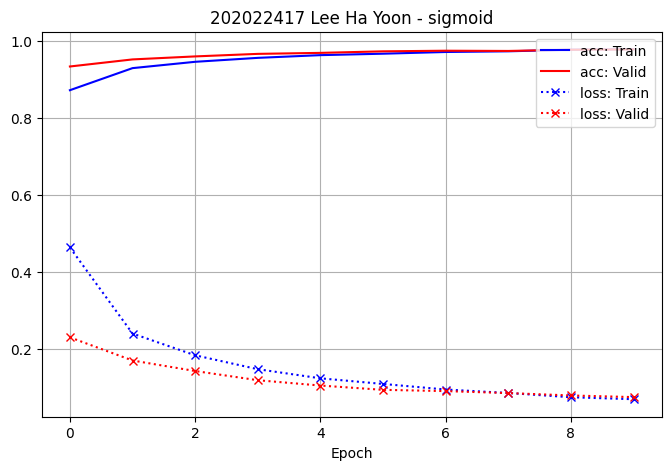

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - sigmoid')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()

In [ ]:
###A-3###

In [ ]:
#########################################
###문제 A-3에서 제시한 최선의 학습모델###
###  SGD 알고리즘, ReLU 함수를 이용   ###
#########################################

In [ ]:
import tensorflow as tf

In [ ]:
mnist = tf.keras.datasets.mnist

# MNIST 데이터 로딩: #(train data)=60,000, #(test data)=10,000
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# 60,000개의 data --> 훈련(train)데이터, 검증(validation) 데이터로 나눔
x_valid, x_train = x_train_full[:5000], x_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]


In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # 입력층 : 뉴런 수 28x28
  tf.keras.layers.Dense(128, activation='relu'),  # 활성화 함수 선택:  ReLU
  tf.keras.layers.Dropout(0.2),                   # dropout 비율: 0.2
  tf.keras.layers.Dense(10, activation='softmax') # 출력층: 뉴런 수 10개, 활성화함수(Softmax)
])

model.compile(optimizer='sgd',                     #최적화 알고리즘 선택: sgd
              loss='sparse_categorical_crossentropy', #cross-entropy 함수
              metrics=['accuracy'])

In [ ]:
History = model.fit(x_train, \
                    y_train, \
                    epochs=10,\
                    validation_data=(x_valid,y_valid))   # 최대 epoch 수 : 10회

print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7611 - accuracy: 0.7899 - val_loss: 0.3790 - val_accuracy: 0.8988
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4004 - accuracy: 0.8854 - val_loss: 0.2994 - val_accuracy: 0.9182
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3348 - accuracy: 0.9052 - val_loss: 0.2577 - val_accuracy: 0.9302
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2959 - accuracy: 0.9162 - val_loss: 0.2333 - val_accuracy: 0.9392
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2679 - accuracy: 0.9241 - val_loss: 0.2124 - val_accuracy: 0.9428
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2481 - accuracy: 0.9295 - val_loss: 0.1962 - val_accuracy: 0.9476
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2309 - accuracy: 0.9343 - val_loss: 0.1830 - val_accuracy:

[0.15748311579227448, 0.954200029373169]

In [ ]:
History.history

{'loss': [0.7611420750617981,
  0.4004005789756775,
  0.3348137438297272,
  0.29591646790504456,
  0.2679188549518585,
  0.24808120727539062,
  0.23085962235927582,
  0.21632693707942963,
  0.20535440742969513,
  0.19534385204315186],
 'accuracy': [0.7899454832077026,
  0.885418176651001,
  0.9052000045776367,
  0.9161636233329773,
  0.9240909218788147,
  0.9295091032981873,
  0.934290885925293,
  0.9395090937614441,
  0.9422000050544739,
  0.9450363516807556],
 'val_loss': [0.37895941734313965,
  0.2993808090686798,
  0.25767356157302856,
  0.23334887623786926,
  0.2123900204896927,
  0.19616903364658356,
  0.1829518973827362,
  0.17271581292152405,
  0.1625758856534958,
  0.15492916107177734],
 'val_accuracy': [0.8988000154495239,
  0.9182000160217285,
  0.9301999807357788,
  0.9391999840736389,
  0.942799985408783,
  0.9476000070571899,
  0.9498000144958496,
  0.9531999826431274,
  0.9571999907493591,
  0.9580000042915344]}

In [ ]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_8 (Dense)             (None, 128)               100480    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


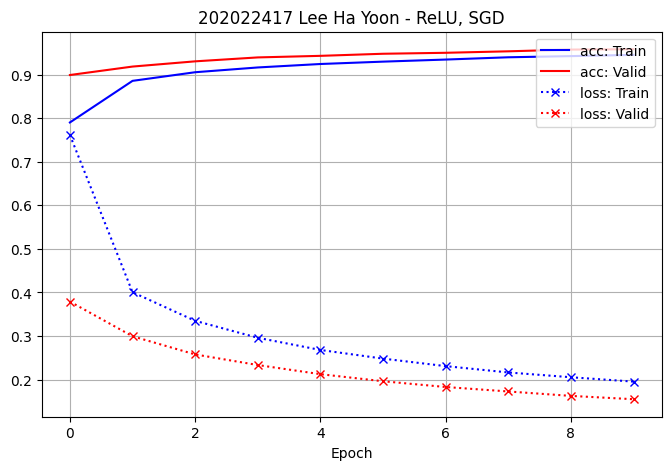

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - ReLU, SGD')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()

In [ ]:
###B - CNN기반의 학습모델###

In [ ]:
import numpy as np
from tensorflow import keras
import tensorflow as tf

mnist = tf.keras.datasets.mnist

# MNIST 데이터 로딩: #(train data)=60,000, #(test data)=10,000
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data() #데이터
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0
x_train, x_valid = x_train_full[:-5000], x_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

x_mean = x_train.mean(axis=0, keepdims=True)
x_std = x_train.std(axis=0, keepdims=True) + 1e-7
x_train = (x_train - x_mean) / x_std
x_valid = (x_valid - x_mean) / x_std
x_test = (x_test - x_mean) / x_std

x_train = x_train[..., np.newaxis]
x_valid = x_valid[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [ ]:
from functools import partial

DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

# 모델(인공 신경망) 구축
model = keras.models.Sequential([
    DefaultConv2D(filters=128, kernel_size=3, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2, strides=4),

    DefaultConv2D(filters=128, activation="sigmoid"),
    keras.layers.MaxPooling2D(pool_size=2, strides=4),

    # 완전 연결 층
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.7),

    # 출력층
    keras.layers.Dense(units=10, activation='softmax'), #뉴런수 10개, 활성화함수 Softmax 이용
])

In [ ]:
# 모델 컴파일
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# 모델 학습
History = model.fit(x_train, y_train, epochs=8, validation_data=(x_valid, y_valid))
print()
print('---------------------------------------')
print('Evaluation 결과: test 데이터 이용')
model.evaluate(x_test,  y_test, verbose=1)

In [ ]:
History.history

In [ ]:
model.summary()

In [ ]:
## 학습과정 및 결과에 대한 이력 시각화: 예-2
import matplotlib.pyplot as plt

# history의 객체 시각화 (정확도, 손실)
plt.figure(figsize=(8,5))
plt.plot(History.history['accuracy'], 'b')
plt.plot(History.history['val_accuracy'], 'r')
plt.plot(History.history['loss'], 'bx:')
plt.plot(History.history['val_loss'], 'rx:')
plt.title('202022417 Lee Ha Yoon - CNN')
plt.xlabel('Epoch')
plt.grid()
plt.legend(['acc: Train', 'acc: Valid', 'loss: Train', 'loss: Valid'], loc='upper right')
plt.show()